# Solar cycle length vs. Northern Hemisphere temperature: which gaps in the methods matter?

This notebook makes the figures for the Correlations scenario of the LilyPad *Are Methods Actionable?*.
It re-creates Fig. 2 of [Friis-Christensen & Lassen (1991)](https://doi.org/10.1126/science.254.5032.698)
under different readings of three things their methods section leaves open:

1. how the dates of sunspot maxima and minima were found,
2. how the end of the record was handled ("estimating the next extremum"),
3. how temperature was smoothed ("smoothed by Jones").

The paper claims "a close association between the two curves [...] since 1970". The point of the exercise
is that some of these gaps change whether that claim holds, and others don't. No correlation is computed,
because the paper didn't compute one. The full analysis (correlation, significance, detrending, longer
records) is the Deep End notebook, `deep-water/correlation-workflow/correlation/workflow.ipynb`.

Students will not run this notebook: it is the engine for a point-and-click LilyPad. Every decision
a learner can make is a variable in the **Choices** cell (section 2). Everything else is fixed.

**Steps:** check package versions → set choices → get data → find sunspot extrema → cycle lengths →
temperature → plot → save a record of the run → precompute every combination.

## 1. Package versions

Compares the installed packages with the exact versions pinned in `requirements.txt`. A mismatch doesn't stop the notebook, but results may differ from the recorded ones.

In [1]:
import json, platform, datetime, urllib.request
import importlib.metadata as md
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

HERE = Path.cwd()
DATA_DIR = HERE / "data"
DATA_DIR.mkdir(exist_ok=True)

versions = {"python": platform.python_version()}
print(f"{'package':<12}{'required':<12}{'installed':<12}ok?")
for line in (HERE / "requirements.txt").read_text().splitlines():
    line = line.strip()
    if not line or line.startswith("#"):
        continue
    pkg, required = line.split("==")
    installed = md.version(pkg)
    versions[pkg] = installed
    print(f"{pkg:<12}{required:<12}{installed:<12}{'yes' if installed == required else 'NO'}")
print(f"\nPython {platform.python_version()} (results were recorded with 3.12.0)")

package     required    installed   ok?
numpy       2.4.6       2.4.6       yes
scipy       1.17.1      1.17.1      yes
pandas      3.0.3       3.0.3       yes
matplotlib  3.10.8      3.10.8      yes

Python 3.12.0 (results were recorded with 3.12.0)


## 2. Choices

These are the decisions a learner makes in the LilyPad. The values set below reproduce the LilyPad's
Figure 1, so this cell is also the answer key.

| Choice | Options | What it means |
|---|---|---|
| `EXTREMA` | `"13month"`, `"yearly"`, `"monthly"` | Which sunspot series the maxima and minima are picked from: the standard 13-month running mean of monthly values (as SILSO does), yearly means, or the raw monthly values. |
| `END_OF_RECORD` | `"average"`, `"last"`, `"leave_out"` | The paper smooths the last-but-one extremum date "by estimating the next extremum", and leaves the last one unsmoothed. `"average"` estimates the next extremum as the last date plus the average cycle length, `"last"` as the last date plus the most recent cycle length. `"leave_out"` doesn't follow the paper: dates that can't be fully smoothed are dropped. |
| `TEMPERATURE` | `"12221"`, `"none"`, `"running11"` | How temperature is smoothed, which the paper only describes as "smoothed by Jones". `"12221"` applies the same 1-2-2-2-1 filter as for the cycle dates to the half-cycle averages; `"none"` uses the half-cycle averages as they are; `"running11"` averages yearly temperatures over 11-year windows before taking half-cycle averages. |

`END_YEAR` and `BASELINE` are fixed settings, not learner choices: the record stops in 1990, as for the
paper, and temperatures are anomalies relative to 1951–1980, as in the paper.

In [2]:
EXTREMA       = "13month"    # "13month" | "yearly" | "monthly"
END_OF_RECORD = "average"    # "average" | "last" | "leave_out"
TEMPERATURE   = "12221"      # "12221" | "none" | "running11"

# Fixed settings (not exposed to learners)
END_YEAR = 1990              # data after this year are ignored, as in the 1991 paper
BASELINE = (1951, 1980)      # reference period for temperature anomalies, as in the paper
CLAIM    = (1970, END_YEAR)  # the paper's "since 1970", shaded in the figures

assert EXTREMA in ("13month", "yearly", "monthly")
assert END_OF_RECORD in ("average", "last", "leave_out")
assert TEMPERATURE in ("12221", "none", "running11")

## 3. Data

| Series | Source | File |
|---|---|---|
| Monthly mean total sunspot number (version 2) | [WDC-SILSO](https://www.sidc.be/SILSO/datafiles), Royal Observatory of Belgium | `data/silso_sunspots_monthly.csv` |
| CRUTEM5 Northern Hemisphere land temperature anomalies, monthly | [Met Office Hadley Centre / CRU](https://www.metoffice.gov.uk/hadobs/crutem5/) | `data/crutem5_nh_monthly.csv` |

These are the same files as in the Deep End notebook. The notebook downloads each file only if it isn't
already in `data/`, and records the download date in `data/sources.json`.

In [3]:
SOURCES = {
    "silso_sunspots_monthly.csv": "https://www.sidc.be/SILSO/INFO/snmtotcsv.php",
    "crutem5_nh_monthly.csv": "https://www.metoffice.gov.uk/hadobs/crutem5/data/CRUTEM.5.0.2.0/diagnostics/CRUTEM.5.0.2.0.summary_series.northern_hemisphere.monthly.csv",
}
sources_file = DATA_DIR / "sources.json"
sources_log = json.loads(sources_file.read_text()) if sources_file.exists() else {}

for fname, url in SOURCES.items():
    path = DATA_DIR / fname
    if not path.exists():
        print(f"Downloading {fname} ...")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        path.write_bytes(urllib.request.urlopen(req, timeout=60).read())
        sources_log[fname] = {"url": url, "retrieved": datetime.date.today().isoformat()}
    print(f"{fname}: retrieved {sources_log.get(fname, {}).get('retrieved', 'unknown')}")
sources_file.write_text(json.dumps(sources_log, indent=2))

# Sunspots: semicolon-separated, no header; -1 marks missing values
sunspots = pd.read_csv(DATA_DIR / "silso_sunspots_monthly.csv", sep=";", header=None,
                       usecols=[0, 1, 2, 3], names=["year", "month", "time", "ssn"])
sunspots = sunspots[(sunspots["ssn"] >= 0) & (sunspots["time"] <= END_YEAR + 1)].reset_index(drop=True)

temperature = pd.read_csv(DATA_DIR / "crutem5_nh_monthly.csv")
temperature = temperature.rename(columns={"Time": "date", "Anomaly (deg C)": "anomaly"})[["date", "anomaly"]]
temperature["year"] = temperature["date"].str[:4].astype(int)
temperature["time"] = temperature["year"] + (temperature["date"].str[5:7].astype(int) - 0.5) / 12
temperature = temperature[temperature["time"] <= END_YEAR + 1].reset_index(drop=True)
in_base = temperature["year"].between(*BASELINE)
temperature["anomaly"] = temperature["anomaly"] - temperature.loc[in_base, "anomaly"].mean()

print(f"Sunspots:    {sunspots['time'].iloc[0]:.1f} to {sunspots['time'].iloc[-1]:.1f}")
print(f"Temperature: {temperature['date'].iloc[0]} to {temperature['date'].iloc[-1]}")

silso_sunspots_monthly.csv: retrieved 2026-09-30
crutem5_nh_monthly.csv: retrieved 2026-09-30
Sunspots:    1749.0 to 1991.0
Temperature: 1850-01 to 1990-12


## 4. Dates of sunspot maxima and minima (`EXTREMA`)

The paper takes the dates of maxima and minima from a reference (Gleissberg) without saying how they were
found. Here they are the peaks and troughs of one of three sunspot series. Cycles are about 11 years long,
so extrema must be at least 7 years apart.

In [4]:
def find_extrema(extrema):
    if extrema == "13month":
        weights = np.r_[0.5, np.ones(11), 0.5] / 12          # half weights on the end months
        value = np.convolve(sunspots["ssn"], weights, mode="valid")
        time = sunspots["time"].to_numpy()[6:-6]
        min_gap = 84                                          # months
    elif extrema == "monthly":
        value, time, min_gap = sunspots["ssn"].to_numpy(), sunspots["time"].to_numpy(), 84
    else:                                                     # yearly means of complete years
        yearly = sunspots.groupby("year")["ssn"].agg(["mean", "count"])
        yearly = yearly[yearly["count"] == 12]
        value, time, min_gap = yearly["mean"].to_numpy(), yearly.index.to_numpy() + 0.5, 7
    t_min = time[find_peaks(-value, distance=min_gap, prominence=20)[0]]
    t_max = time[find_peaks(value, distance=min_gap, prominence=20)[0]]
    return t_min, t_max

t_min, t_max = find_extrema(EXTREMA)
print("Minima:", np.round(t_min[t_min > 1840], 1))
print("Maxima:", np.round(t_max[t_max > 1840], 1))

Minima: [1843.5 1856.  1867.2 1879.  1890.2 1902.  1913.5 1923.6 1933.7 1944.1
 1954.3 1964.8 1976.2 1986.7]
Maxima: [1848.1 1860.1 1870.6 1884.  1894.  1906.1 1917.6 1928.3 1937.3 1947.4
 1958.2 1968.9 1980.  1989.9]


## 5. Solar cycle lengths (`END_OF_RECORD`)

As in the paper, the dates of maxima and of minima are each smoothed with a 1-2-2-2-1 weighted running
mean over five consecutive dates of the same kind. Cycle lengths are the differences between consecutive
smoothed dates, plotted at the center of each cycle.

The last two dates of each kind can't be fully smoothed. The paper smooths the last-but-one "by estimating
the next extremum" (which gets a weight of only 1/8) and leaves the last one unsmoothed, without saying how
the next extremum was estimated. `"average"` and `"last"` are two guesses; `"leave_out"` drops these dates instead.

In [5]:
W5 = np.array([1, 2, 2, 2, 1]) / 8

def smooth_dates(t, end_of_record):
    n = len(t)
    out = np.full(n, np.nan)
    for i in range(2, n - 2):
        out[i] = W5 @ t[i - 2:i + 3]
    if end_of_record != "leave_out":
        step = np.diff(t).mean() if end_of_record == "average" else t[-1] - t[-2]
        out[n - 2] = W5 @ np.r_[t[n - 4:n], t[-1] + step]     # estimated next extremum
        out[n - 1] = t[-1]                                    # unsmoothed
    return out

def cycle_lengths(t_min, t_max, end_of_record):
    parts = [pd.DataFrame({"time": (t[1:] + t[:-1]) / 2, "length": np.diff(smooth_dates(t, end_of_record))})
             for t in (t_min, t_max)]
    return pd.concat(parts).sort_values("time").dropna().reset_index(drop=True)

scl = cycle_lengths(t_min, t_max, END_OF_RECORD)
print(f"{len(scl)} cycle lengths, last one centered on {scl['time'].iloc[-1]:.1f}")

38 cycle lengths, last one centered on 1984.9


## 6. Temperature (`TEMPERATURE`)

As in the paper's Fig. 1, monthly anomalies are averaged over each half solar cycle (maximum to minimum,
minimum to maximum) and placed at its center. The paper's temperature series was "smoothed by Jones",
with no further detail.

- `"12221"`: the same 1-2-2-2-1 filter as for the cycle dates, over five consecutive half cycles of the same kind (rising with rising, falling with falling). At the end of the record it follows `END_OF_RECORD`: with `"leave_out"`, values without enough neighbours are dropped; otherwise the last-but-one value uses the four available weights and the last is left unsmoothed (a next half cycle can't be estimated).
- `"none"`: the half-cycle averages as they are.
- `"running11"`: yearly means are first averaged over centered 11-year windows, then averaged over each half cycle.

In [6]:
def half_cycle_means(t_min, t_max, time, value):
    extrema = np.sort(np.r_[t_min, t_max])
    rows = []
    for e0, e1 in zip(extrema[:-1], extrema[1:]):
        inside = (time >= e0) & (time < e1) & ~np.isnan(value)
        if e0 >= time[0] and e1 <= time[-1] and inside.any():
            rows.append({"time": (e0 + e1) / 2, "anomaly": value[inside].mean(),
                         "kind": "rising" if e0 in t_min else "falling"})
    return pd.DataFrame(rows)

def smooth_halves(half, end_of_record):
    out = half.copy()
    for kind in ("rising", "falling"):
        idx = half.index[half["kind"] == kind]
        v = half.loc[idx, "anomaly"].to_numpy()
        n = len(v)
        sm = np.full(n, np.nan)
        for i in range(2, n - 2):
            sm[i] = W5 @ v[i - 2:i + 3]
        if end_of_record != "leave_out":
            sm[n - 2] = np.dot([1, 2, 2, 2], v[n - 4:n]) / 7
            sm[n - 1] = v[-1]
        out.loc[idx, "anomaly"] = sm
    return out

def temperature_series(t_min, t_max, smoothing, end_of_record):
    if smoothing == "running11":
        yearly = temperature.groupby("year")["anomaly"].agg(["mean", "count"])
        yearly = yearly[yearly["count"] == 12]
        value = yearly["mean"].rolling(11, center=True).mean().to_numpy()
        half = half_cycle_means(t_min, t_max, yearly.index.to_numpy() + 0.5, value)
    else:
        half = half_cycle_means(t_min, t_max, temperature["time"].to_numpy(), temperature["anomaly"].to_numpy())
        if smoothing == "12221":
            half = smooth_halves(half, end_of_record)
    return half.dropna().reset_index(drop=True)

temp = temperature_series(t_min, t_max, TEMPERATURE, END_OF_RECORD)
print(f"{len(temp)} temperature values, last one centered on {temp['time'].iloc[-1]:.1f}")

21 temperature values, last one centered on 1988.3


## 7. Figure

Solar cycle length is plotted on an inverted axis (short cycles up), as in the 1991 paper, so the claimed
association shows up as the two curves moving together. The shaded band is the period of the claim
"since 1970".

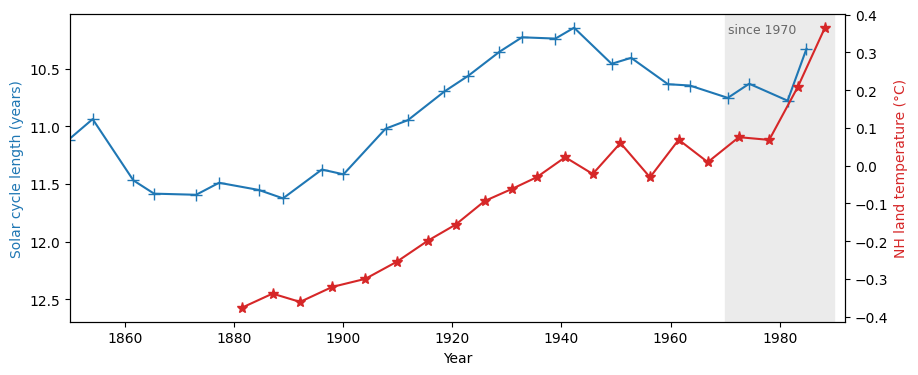

In [7]:
def plot_pair(scl, temp):
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.axvspan(*CLAIM, color="0.92", zorder=0)
    ax1.text(CLAIM[0] + 0.5, 0.97, "since 1970", transform=ax1.get_xaxis_transform(),
             va="top", fontsize=9, color="0.4")
    ax1.plot(scl["time"], scl["length"], "+-", color="tab:blue", lw=1.5, ms=8)   # symbols as in the paper
    ax1.set_ylabel("Solar cycle length (years)", color="tab:blue")
    ax1.invert_yaxis()
    ax2 = ax1.twinx()
    ax2.plot(temp["time"], temp["anomaly"], "*-", color="tab:red", lw=1.5, ms=8)
    ax2.set_ylabel("NH land temperature (°C)", color="tab:red")
    ax1.set(xlabel="Year", xlim=(1850, END_YEAR + 2))
    return fig

plot_pair(scl, temp)
plt.show()

## 8. Record of this run

Saves the choices, package versions and data retrieval dates together in `outputs/`, so any figure can be
traced back to exactly how it was made.

In [8]:
out_dir = HERE / "outputs"
out_dir.mkdir(exist_ok=True)
record = {
    "choices": {"extrema": EXTREMA, "end_of_record": END_OF_RECORD, "temperature": TEMPERATURE},
    "fixed_settings": {"end_year": END_YEAR, "baseline": list(BASELINE)},
    "result": {"last_cycle_length_center": round(float(scl["time"].iloc[-1]), 1),
               "last_temperature_center": round(float(temp["time"].iloc[-1]), 1)},
    "versions": versions,
    "data": sources_log,
    "run_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
fname = f"extrema-{EXTREMA}__end-{END_OF_RECORD}__temperature-{TEMPERATURE}.json"
(out_dir / fname).write_text(json.dumps(record, indent=2))
print(f"Saved outputs/{fname}")

Saved outputs/extrema-13month__end-average__temperature-12221.json


## 9. Precompute every combination for the LilyPad

The LilyPad page doesn't run Python. It looks up the precomputed figures in `images/manifest.json`
(3 × 3 × 3 = 27 figures), plus `figure1.png` for the choices in section 2.

In [9]:
from itertools import product

img_dir = HERE / "images"
img_dir.mkdir(exist_ok=True)

manifest = []
for ex, end, tp in product(("13month", "yearly", "monthly"), ("average", "last", "leave_out"),
                           ("12221", "none", "running11")):
    tmin, tmax = find_extrema(ex)
    fig = plot_pair(cycle_lengths(tmin, tmax, end), temperature_series(tmin, tmax, tp, end))
    image = f"extrema-{ex}__end-{end}__temperature-{tp}.png"
    fig.savefig(img_dir / image, dpi=150, bbox_inches="tight")
    plt.close(fig)
    manifest.append({"extrema": ex, "end": end, "temperature": tp, "image": f"correlation/images/{image}"})

(img_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))

fig = plot_pair(scl, temp)
fig.savefig(img_dir / "figure1.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Saved {len(manifest)} figures, manifest.json and figure1.png to images/")

Saved 27 figures, manifest.json and figure1.png to images/
